In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

# Integrating $m_{Fe}^{Ia}$ numerically

$ m_{Fe}^{Ia} = \int_{t_D}^{t_{max}}{K_{Fe}^{Ia}(t)R_{Ia}(t)dt}$

Model1 is without metallicity dependance


Model2 is with metallicity dependance, but with constant $K_{Fe}^{Ia}$

In [19]:
#No metallicity dependance
t_array = np.linspace(0,14,int(1e3))
m_g_array_const = np.ones(len(t_array))
gal1 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const)
Z_Fe_1 = gal1.compute_z_Fe()
Z_O_1 = gal1.compute_z_O()
eq_Fe_1 = gal1.analytic_eq_Fe(SFR_function="constant")

In [20]:
#Metallicity dependance
K_Fe_Ia= np.ones(len(t_array)) * 0.77
gal2 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, metallicity_dep_flag=1, K_Fe_Ia=K_Fe_Ia)
Z_Fe_2 = gal2.compute_z_Fe()
Z_O_2 = gal2.compute_z_O()
eq_Fe_2 = gal2.analytic_eq_Fe(SFR_function="constant")

Text(0, 0.5, '$Z_{Fe}$')

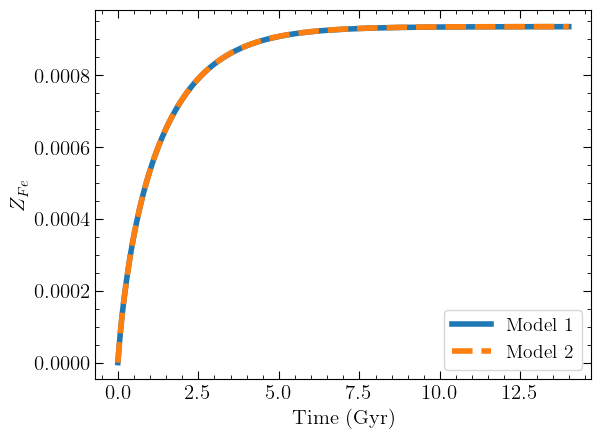

In [21]:
plt.plot(t_array, Z_Fe_1, label = 'Model 1', lw = 4)
plt.plot(t_array, Z_Fe_2, label = 'Model 2', linestyle = '--', lw=4)
plt.legend(fontsize=14)
plt.xlabel('Time (Gyr)')
plt.ylabel(r'$Z_{Fe}$')

In [5]:
SolarO=0.0056		# solar oxygen abundance by mass
SolarFe=0.0012		# solar iron abundance by mass

def ratio_to_sun(star, sun):
    ratio = np.log10(star/sun + 1e-10)
    ratio[np.where(ratio <= -10)] = 0
    return ratio

Fe_H_model1 = ratio_to_sun(Z_Fe_1, SolarFe)
O_H_model1 = ratio_to_sun(Z_O_1, SolarO)
O_Fe_model1 = O_H_model1 - Fe_H_model1
Fe_O_model1 = Fe_H_model1 - O_H_model1

Fe_H_model2 = ratio_to_sun(Z_Fe_2, SolarFe)
O_H_model2 = ratio_to_sun(Z_O_2, SolarO)
O_Fe_model2 = O_H_model2 - Fe_H_model2
Fe_O_model2 = Fe_H_model2 - O_H_model2

Text(0, 0.5, '[O/Fe]')

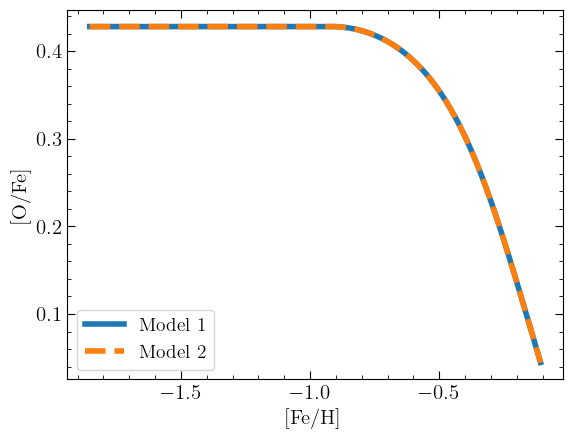

In [6]:
plt.plot(Fe_H_model1[1:], O_Fe_model1[1:], label = 'Model 1', lw = 4)
plt.plot(Fe_H_model2[1:], O_Fe_model2[1:], label = 'Model 2', lw = 4, linestyle = '--')

plt.legend(fontsize=14)
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

Text(0, 0.5, '[O/Fe]')

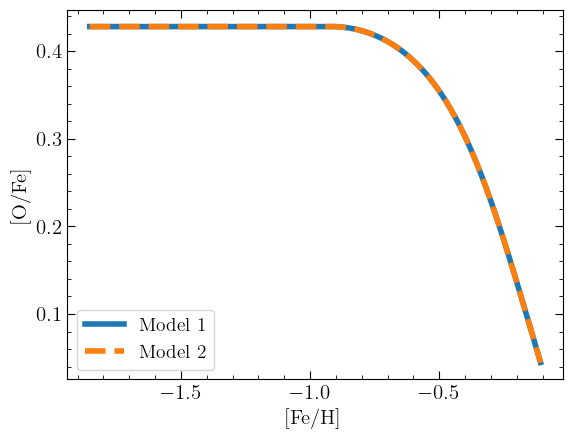

In [7]:
plt.plot(gal1.Fe_H[1:], O_Fe_model1[1:], label = 'Model 1', lw = 4)
plt.plot(Fe_H_model2[1:], O_Fe_model2[1:], label = 'Model 2', lw = 4, linestyle = '--')

plt.legend(fontsize=14)
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

Text(0, 0.5, '[Fe/O]')

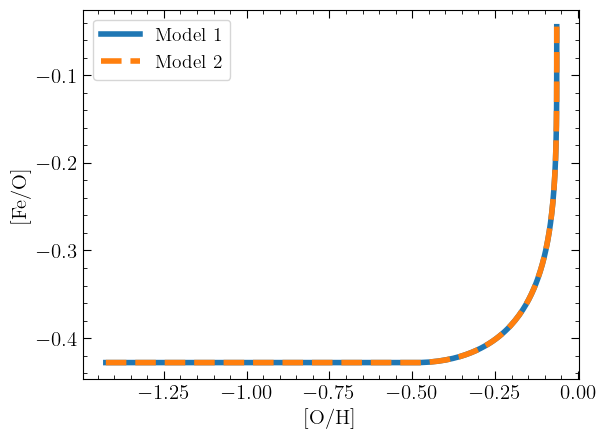

In [8]:
plt.plot(O_H_model1[1:], Fe_O_model1[1:], label = 'Model 1', lw = 4)
plt.plot(O_H_model2[1:], Fe_O_model2[1:], label = 'Model 2', lw = 4, linestyle = '--')

plt.legend(fontsize=14)
plt.xlabel('[O/H]')
plt.ylabel('[Fe/O]')

# IMF averaged metallicity dependant yields

In [9]:
def get_y_x(y_ref, Z_x_solar, Z_ref_solar, alpha_cc, Z_ref_normalized):
    """
    Eq. 17 in W2019
    Parameters
    ----------
    y_ref : float
        Ref element yield. 
    Z_x_solar : float
        Element X abundance in the Sun
    Z_ref_solar : float
        Ref element abundance in the Sun
    alpha_cc : float
        Slope alpha
    Z_ref_normalized : ndarray
        [REF/H] for the population

    Returns
    -------
    y_X : ndarray
        yield for elemnt X dependent on ref metallicity
    """
    y_x = y_ref * (Z_x_solar/Z_ref_solar) * 10**(alpha_cc * Z_ref_normalized)
    return y_x

In [10]:
y_O = gal1.m_o_cc_arr[0]
y_Fe_cc_bench = gal1.m_Fe_cc_arr[0]
y_Fe_Ia_bench = gal1.m_Fe_Ia_arr[0]
y_Fe = get_y_x(y_O, SolarFe, SolarO, alpha_cc=0.2, Z_ref_normalized=O_H_model1)
y_Fe_no_alpha = get_y_x(y_O, SolarFe, SolarO, alpha_cc=0.0, Z_ref_normalized=O_H_model1)

In [22]:
m_Fe_Ia_3 = y_Fe_no_alpha - y_Fe_cc_bench * np.ones(len(t_array))
gal3 = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, m_Fe_Ia=m_Fe_Ia_3)
Z_Fe_3 = gal3.compute_z_Fe()
Z_O_3 = gal3.compute_z_O()

Fe_H_model3 = ratio_to_sun(Z_Fe_3, SolarFe)
O_H_model3 = ratio_to_sun(Z_O_3, SolarO)
O_Fe_model3 = O_H_model3 - Fe_H_model3
Fe_O_model3 = Fe_H_model3 - O_H_model3

Text(0, 0.5, '[O/Fe]')

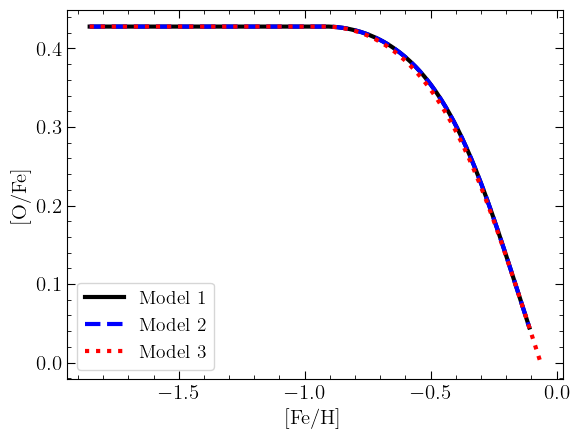

In [25]:
plt.plot(Fe_H_model1[1:], O_Fe_model1[1:], label = 'Model 1', lw = 3, color = 'black')
plt.plot(Fe_H_model2[1:], O_Fe_model2[1:], label = 'Model 2', lw = 3, linestyle = '--', color = 'blue')
plt.plot(Fe_H_model3[1:], O_Fe_model3[1:], label = 'Model 3', lw = 3, linestyle = ':', color = 'red')

plt.legend(fontsize=14)
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')

# A Very arbitrary example: assume $K_{Fe}^{Ia}$ changes linearly from 0 to 0.77 with metallicity

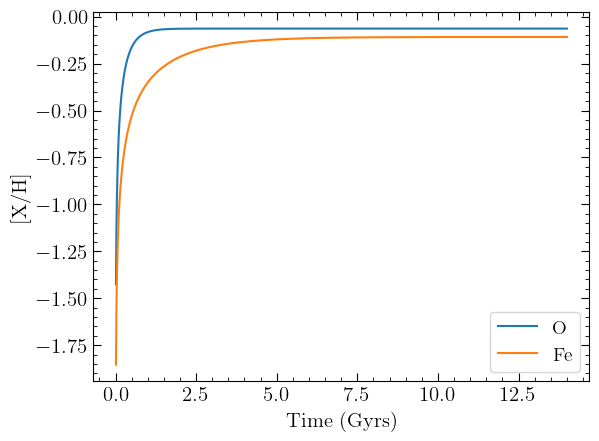

In [ ]:
plt.plot(t_array[1:], O_H_model1[1:], label = 'O')
plt.plot(t_array[1:], Fe_H_model1[1:], label = 'Fe')
plt.xlabel('Time (Gyrs)')
plt.ylabel('[X/H]')
plt.legend(fontsize=14)
plt.title("[X/H] for model 1")

In [26]:
def make_line(x, x1, x2, y1, y2):
    m = (y2 - y1)/(x2 - x1)
    y = m * (x - x1) + y1
    return y

In [27]:
max_O_H = max(O_H_model1[np.where(O_H_model1 != 0)])
min_O_H = min(O_H_model1)

In [36]:
xs = np.linspace(min_O_H, max_O_H, len(t_array))
Ks = make_line(xs, min_O_H, max_O_H, 0, 0.77)
gal4 = evo.Galaxy(t_array, m_g_array = m_g_array_const, metallicity_dep_flag=1, K_Fe_Ia=Ks)
m_Fe_Ia_4 = gal4.m_Fe_Ia_arr
Z_Fe_4 = gal4.compute_z_Fe()
Z_O_4 = gal4.compute_z_O()

Fe_H_model4 = ratio_to_sun(Z_Fe_3, SolarFe)
O_H_model4 = ratio_to_sun(Z_O_3, SolarO)
O_Fe_model4 = O_H_model4 - Fe_H_model4
Fe_O_model4 = Fe_H_model4 - O_H_model4

Model 4 is using a K that changes as a line, starting at 0 at the minimum O_H value, and reaching 0.77 at the maximum O_H value. The results look weirdly similar to what I got with metallicity dependent yield from cartography equation.

Text(0, 0.5, '[O/Fe]')

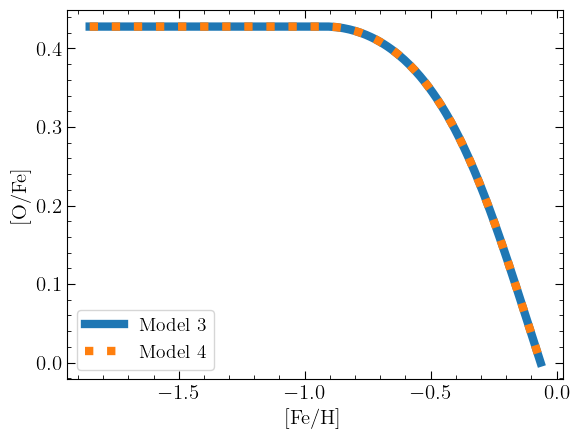

In [37]:
#plt.plot(Fe_H_model1[1:], O_Fe_model1[1:], label = 'Model 1', lw = 6, color = 'black')
#plt.plot(Fe_H_model2[1:], O_Fe_model2[1:], label = 'Model 2', lw = 6, linestyle = '--')
plt.plot(Fe_H_model3[1:], O_Fe_model3[1:], label = 'Model 3', lw = 6, linestyle = '-')
plt.plot(Fe_H_model4[1:], O_Fe_model4[1:], label = 'Model 4', lw = 6, linestyle = ':')

plt.legend(fontsize=14)
plt.xlabel('[Fe/H]')
plt.ylabel('[O/Fe]')